In [1]:
%load_ext autoreload
%autoreload 2

# Comparison of Predictions results acrosse models

In [2]:
import cobra
import pandas

In [3]:
from cobra.core import configuration
configuration.Configuration.solver = 'glpk'

In [4]:
model_paths_dict = {
    'MitoCore_Original_plt': './../parameterized_plt_models/Mitocore_Original_plt.xml',
    'Mitocore_Preliminary': './../autopacmen_output/Mitocore_Preliminary/Mitocore_Preliminary_calibrated.xml',
    'Mitocore_MitoMammal': './../autopacmen_output/Mitocore_MitoMammal/Mitocore_MitoMammal_calibrated.xml',
    # 'Mitocore_aligned_to_Human1': './../autopacmen_output/Mitocore_aligned_to_Human1/Mitocore_aligned_to_Human1_calibrated.xml',
    'Mitocore_aligned_to_Human1': './../autopacmen_output/Mitocore_aligned_to_Human1/MitoCore_aligned_to_Human1_calibrated_MA.xml'
}

In [ ]:
import os
os.getcwd()

'c:\\Users\\Emanu\\git\\mitocore-smoment-model\\smoment\\scripts'

In [5]:
models_dict = {}

for model_name, values in model_paths_dict.items():
    # print(cobra.io.validate_sbml_model(values))
    model = cobra.io.read_sbml_model(values)
    models_dict[model_name] = model

In [36]:
# measured exchange fluxes from sake paper and atp production from jedlicka paper
fba_comparison_dict = {
    "reaction": ["EX_glc_D_e", "EX_ac_e", "EX_lac_L_e", "EX_gln_L_e", "EX_cit_e", "OF_ATP_MitoCore"],
    "name": ["glucose uptake", "acetate uptake", "lactate secretion", "glutamine uptake", "citrate exchange", "ATP production"],
    "measured_flux": [-0.14, -0.44, 0.4, -1, 0, 1.7070],
    "MitoCore_Original_plt": [],
    "Mitocore_Preliminary": [],
    "Mitocore_MitoMammal": [],
    "Mitocore_aligned_to_Human1": [],
}

glyco_oxphos_splits = {
    "model": ["measurement"],
    "glycolysis_fraction": [0.24],
    "oxphos_fraction": [0.76],
    "glycolysis_net_flux": [0.411],
    "oxphos_net_flux": [1.296]
}

# dicts to determine net fluxes through glycolysis and oxphos
# reactions were deterimined by manually searching the ec models with iriginal reaction names
glycolysis_fluxes = {
    "MitoCore_Original_plt":{"PYK": 1, "r0122": 1, "PGK": -1, "HEX1": -1, "PFK": -1},  # PGK is stored as reverse reaction --> negative sign
    "Mitocore_Preliminary":{"PYK_GPRSPLIT_1": 1, "r0122_GPRSPLIT_1": 1, "PGK_GPRSPLIT_1_TG_reverse": 1, "armr_HEX1": -1, "PFK_GPRSPLIT_1": -1},
    "Mitocore_MitoMammal":{"PYK_GPRSPLIT_1": 1, "r0122_GPRSPLIT_1": 1, "PGK_GPRSPLIT_1_TG_reverse": 1, "armr_HEX1": -1, "PFK_GPRSPLIT_1": -1},
    "Mitocore_aligned_to_Human1":{"armr_PYK": 1, "armr_r0122": 1, "armr_PGK_reverse": 1, "armr_HEX1": -1, "armr_PFK": -1}
    }

oxphos_fluxes = {
    "MitoCore_Original_plt": {"CV_MitoCore": 1},
    "Mitocore_Preliminary": {"armr_CV_MitoCore_forward": 1},
    "Mitocore_MitoMammal": {"armr_CV_MitoCore_forward": 1},
    "Mitocore_aligned_to_Human1": {"armr_CV_MitoCore_forward": 1}
    }

# 1) Predicting ATP production fluxes by FBA
This is intended as a test run to check the predicted fluxes of the model. Note that models were calibrated with the upper limit from Standard Deviation for total ATP production, but the measurement is the mean value. 

In [37]:
# calculate glyco vs OXPHOS ATP production fraction
def get_ATP_production_fraction(fluxes, glyco_fluxes, oxphos_fluxes, verbose=False):
    
    # fluxes is an object containing the reaction id as key and the flux value as column
    glyco_net_flux = 0
    oxphos_net_flux = 0
    
    for reaction_id, coefficient in glyco_fluxes.items():
        glyco_net_flux += fluxes[reaction_id] * coefficient
    
    for reaction_id, coefficient in oxphos_fluxes.items():
        oxphos_net_flux += fluxes[reaction_id] * coefficient
    
    total_atp_production = glyco_net_flux + oxphos_net_flux
    glyco_fraction = glyco_net_flux / total_atp_production
    oxphos_fraction = 1 - glyco_fraction
    
    if verbose:
        print(f"Total ATP production by glyco and oxphos: {total_atp_production}, glycolysis: {glyco_net_flux}, OXPHOS: {oxphos_net_flux}")
        print(f"Glycolysis fraction: {glyco_fraction}, OXPHOS fraction: {oxphos_fraction}")
        
    return glyco_fraction, oxphos_fraction, glyco_net_flux, oxphos_net_flux
    

In [10]:
for model_name, model in models_dict.items():
    solution = model.optimize()
    print(model_name)
    
    fluxes = {reaction_name: solution.fluxes[reaction_name] for reaction_name in solution.to_frame().index}
    
    glyco_fraction, oxphos_fraction, glyco_net_flux, oxphos_net_flux = get_ATP_production_fraction(fluxes, glycolysis_fluxes[model_name], oxphos_fluxes[model_name], verbose=True)
    
    glyco_oxphos_splits["model"].append(model_name)
    glyco_oxphos_splits["glycolysis_fraction"].append(glyco_fraction)
    glyco_oxphos_splits["oxphos_fraction"].append(oxphos_fraction)
    glyco_oxphos_splits["glycolysis_net_flux"].append(glyco_net_flux)
    glyco_oxphos_splits["oxphos_net_flux"].append(oxphos_net_flux)
    
    for reaction in fba_comparison_dict["reaction"]:
        flux = solution.fluxes[reaction]
        fba_comparison_dict[model_name].append(flux)

glyco_oxphos_splits_df = pandas.DataFrame(glyco_oxphos_splits)  
fba_comparison_df = pandas.DataFrame(fba_comparison_dict)

MitoCore_Original_plt
Total ATP production by glyco and oxphos: 6.135410919737449, glycolysis: 0.37764, OXPHOS: 5.757770919737449
Glycolysis fraction: 0.061550889572064754, OXPHOS fraction: 0.9384491104279352
Mitocore_Preliminary
Total ATP production by glyco and oxphos: 1.800754191879313, glycolysis: 0.37307999999999986, OXPHOS: 1.4276741918793132
Glycolysis fraction: 0.20717985924033533, OXPHOS fraction: 0.7928201407596647
Mitocore_MitoMammal
Total ATP production by glyco and oxphos: 1.8007541865464138, glycolysis: 0.37307999999999986, OXPHOS: 1.427674186546414
Glycolysis fraction: 0.20717985985389453, OXPHOS fraction: 0.7928201401461055
Mitocore_aligned_to_Human1
Total ATP production by glyco and oxphos: 2.4179740516174104, glycolysis: 0.33879445011255227, OXPHOS: 2.0791796015048583
Glycolysis fraction: 0.14011500656341982, OXPHOS fraction: 0.8598849934365802


In [38]:
fba_comparison_df

,reaction,name,measured_flux,MitoCore_Original_plt,Mitocore_Preliminary,Mitocore_MitoMammal,Mitocore_aligned_to_Human1
0,EX_glc_D_e,glucose uptake,-0.140,-1.859400e-01,-0.185940,-0.185940,-0.185940
1,EX_ac_e,acetate uptake,-0.440,0.000000e+00,0.000000,0.000000,-0.115131
2,EX_lac_L_e,lactate secretion,0.400,-3.543709e-17,0.000000,0.000000,0.326901
3,EX_gln_L_e,glutamine uptake,-1.000,0.000000e+00,0.000000,0.000000,0.000000
4,EX_cit_e,citrate exchange,0.000,0.000000e+00,0.000000,0.000000,0.000000
5,OF_ATP_MitoCore,ATP production,1.707,6.521542e+00,2.194366,2.194366,2.194453


In [11]:
glyco_oxphos_splits_df

,model,glycolysis_fraction,oxphos_fraction,glycolysis_net_flux,oxphos_net_flux
0,measurement,0.240000,0.760000,0.411000,1.296000
1,MitoCore_Original_plt,0.061551,0.938449,0.377640,5.757771
2,Mitocore_Preliminary,0.207180,0.792820,0.373080,1.427674
3,Mitocore_MitoMammal,0.207180,0.792820,0.373080,1.427674
4,Mitocore_aligned_to_Human1,0.140115,0.859885,0.338794,2.079180


# Flux Sampling

In [11]:
# measured exchange fluxes from sake paper and atp production from jedlicka paper
sampling_comparison_dict = {
    "reaction": ["EX_glc_D_e", "EX_ac_e", "EX_lac_L_e", "EX_gln_L_e", "EX_cit_e", "OF_ATP_MitoCore"],
    "name": ["glucose uptake", "acetate uptake", "lactate secretion", "glutamine uptake", "citrate exchange", "ATP production"],
    "measured_flux": [-0.14, -0.44, 0.4, -1, 0, 1.7070],
    "MitoCore_Original_plt": [],
    "Mitocore_Preliminary": [],
    "Mitocore_MitoMammal": [],
    "Mitocore_aligned_to_Human1": [],
}

pdhm_data = {
    "MitoCore_Original_plt": [],
    "Mitocore_Preliminary": [],
    "Mitocore_MitoMammal": [],
    "Mitocore_aligned_to_Human1": []
}

glyco_oxphos_splits_sampling = {
    "model": [],
    "glycolysis_fraction": [],
    "oxphos_fraction": [],
    "glycolysis_net_flux": [],
    "oxphos_net_flux": [],
}

In [6]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import time
import statistics
import hopsy
import os
import pickle
from PolyRound.api import PolyRoundApi

from utilities.kcat_sensitivity import scale_pseudo_metabolite_stoichiometry

# Scale the kcats and protein constraints

In [7]:
def get_constraint_distribution(model, model_name):
    constraint_ranges = []
    stoichiometric_coefficients = []
    
    for reaction in model.reactions:
        constraint_ranges.append(reaction.upper_bound - reaction.lower_bound)
        coeff = [abs(coeff) for coeff in reaction.metabolites.values()]
        stoichiometric_coefficients = stoichiometric_coefficients + coeff
        
        if max(coeff) > 1000:
            print(f"Reaction {reaction.id} has a large stoichiometric coefficient: {max(coeff)}")
            print(reaction.metabolites)#
                    
    fig, axs = plt.subplots(1, 2, sharey=True, tight_layout=True)
    
    axs[0].hist(constraint_ranges, bins=100)
    axs[1].hist(stoichiometric_coefficients, bins=100)
    
    axs[0].set_xscale("log")
    axs[1].set_xscale("log")
    
    axs[0].set_title(f"{model_name} constraint ranges")
    axs[1].set_title(f"{model_name} stoichiometric coefficients")
    
    print('min constraint range:', min(constraint_ranges)
          ,'max constraint range:', max(constraint_ranges))
    print('min stoichiometric coefficient:', min(stoichiometric_coefficients)
          ,'max stoichiometric coefficient:', max(stoichiometric_coefficients))
    plt.show()

<Solution 6.522 at 0x1902e570280>
min constraint range: 0.0 max constraint range: 2000.0
min stoichiometric coefficient: 0.002 max stoichiometric coefficient: 8.0


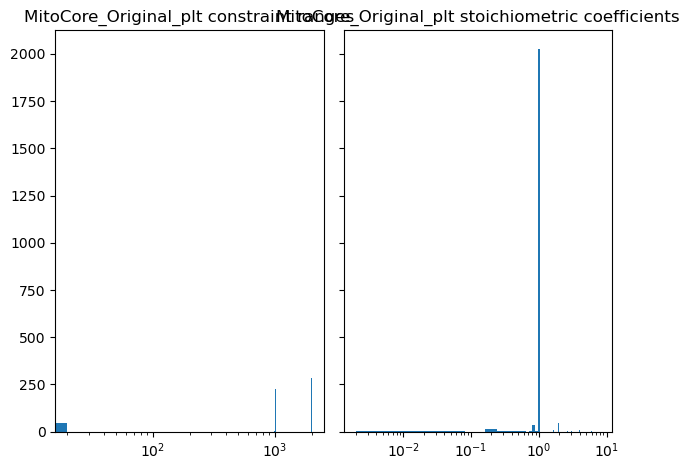

<Solution 2.194 at 0x19030b45fc0>
Reaction GPAMm_hsB_MitoCore has a large stoichiometric coefficient: 2387.3396390519697
{<Metabolite pmtcoa_m at 0x190254c2dd0>: -1.0, <Metabolite glyc3p_m at 0x19025498c70>: -1.0, <Metabolite prot_pool at 0x19025901840>: -2387.3396390519697, <Metabolite coa_m at 0x19025499a50>: 1.0, <Metabolite alpa_hs_m at 0x1902549af80>: 1.0}
Reaction GluForTx_TG_forward has a large stoichiometric coefficient: 1779.19685990338
{<Metabolite h_c at 0x190254c0670>: -1.0, <Metabolite thf_c at 0x190254c1d80>: -1.0, <Metabolite forglu_c at 0x19025498e80>: -1.0, <Metabolite prot_pool at 0x19025901840>: -1779.19685990338, <Metabolite glu_L_c at 0x19025498850>: 1.0, <Metabolite 5forthf_c at 0x1902549bc70>: 1.0}
Reaction GluForTx_TG_reverse has a large stoichiometric coefficient: 1779.19685990338
{<Metabolite glu_L_c at 0x19025498850>: -1.0, <Metabolite 5forthf_c at 0x1902549bc70>: -1.0, <Metabolite prot_pool at 0x19025901840>: -1779.19685990338, <Metabolite h_c at 0x190254c06

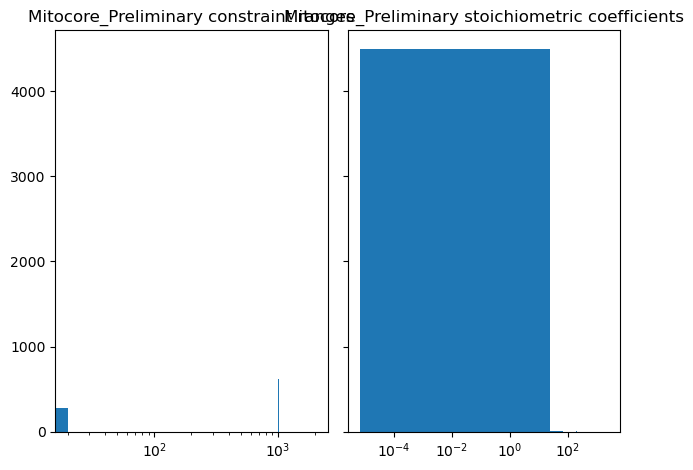

<Solution 2.194 at 0x1902e4f1300>
Reaction GPAMm_hsB_MitoCore has a large stoichiometric coefficient: 2387.3396390519697
{<Metabolite pmtcoa_m at 0x19026adc970>: -1.0, <Metabolite glyc3p_m at 0x19026ac6d10>: -1.0, <Metabolite prot_pool at 0x19026b169e0>: -2387.3396390519697, <Metabolite coa_m at 0x19026aac7f0>: 1.0, <Metabolite alpa_hs_m at 0x19026aadba0>: 1.0}
Reaction GluForTx_TG_forward has a large stoichiometric coefficient: 1779.19685990338
{<Metabolite h_c at 0x19026ac6f20>: -1.0, <Metabolite thf_c at 0x19026afa650>: -1.0, <Metabolite forglu_c at 0x19026ac55d0>: -1.0, <Metabolite prot_pool at 0x19026b169e0>: -1779.19685990338, <Metabolite glu_L_c at 0x19026ac57b0>: 1.0, <Metabolite 5forthf_c at 0x19026a9a110>: 1.0}
Reaction GluForTx_TG_reverse has a large stoichiometric coefficient: 1779.19685990338
{<Metabolite glu_L_c at 0x19026ac57b0>: -1.0, <Metabolite 5forthf_c at 0x19026a9a110>: -1.0, <Metabolite prot_pool at 0x19026b169e0>: -1779.19685990338, <Metabolite h_c at 0x19026ac6f

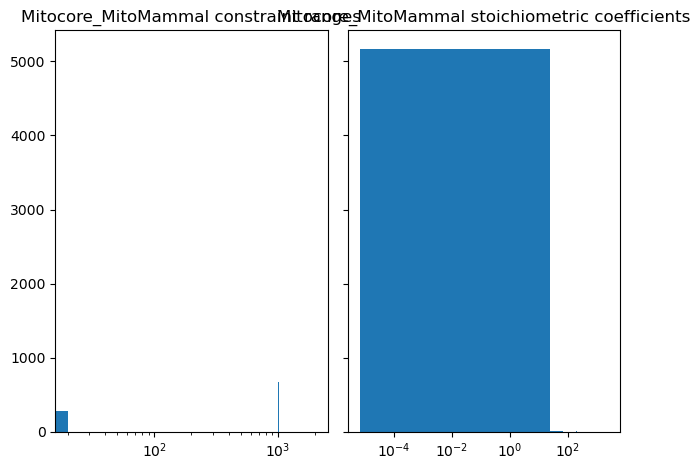

<Solution 2.194 at 0x1902e0f1510>
Reaction GPAMm_hsB_MitoCore_GPRSPLIT_1 has a large stoichiometric coefficient: 1323.7932159165
{<Metabolite pmtcoa_m at 0x1902837f580>: -1.0, <Metabolite glyc3p_m at 0x190283626e0>: -1.0, <Metabolite prot_pool at 0x190283db010>: -1323.7932159165, <Metabolite coa_m at 0x19028362290>: 1.0, <Metabolite alpa_hs_m at 0x1902834d150>: 1.0, <Metabolite armm_GPAMm_hsB_MitoCore at 0x190283dad70>: 1.0}
Reaction GPAMm_hsB_MitoCore_GPRSPLIT_2 has a large stoichiometric coefficient: 1415.28049575995
{<Metabolite pmtcoa_m at 0x1902837f580>: -1.0, <Metabolite glyc3p_m at 0x190283626e0>: -1.0, <Metabolite ENZYME_ENSG00000158669 at 0x190282dbdc0>: -27.179821700369597, <Metabolite prot_pool at 0x190283db010>: -1415.28049575995, <Metabolite coa_m at 0x19028362290>: 1.0, <Metabolite alpa_hs_m at 0x1902834d150>: 1.0, <Metabolite armm_GPAMm_hsB_MitoCore at 0x190283dad70>: 1.0}
Reaction GluForTx_TG_forward has a large stoichiometric coefficient: 1779.19685990338
{<Metabolite 

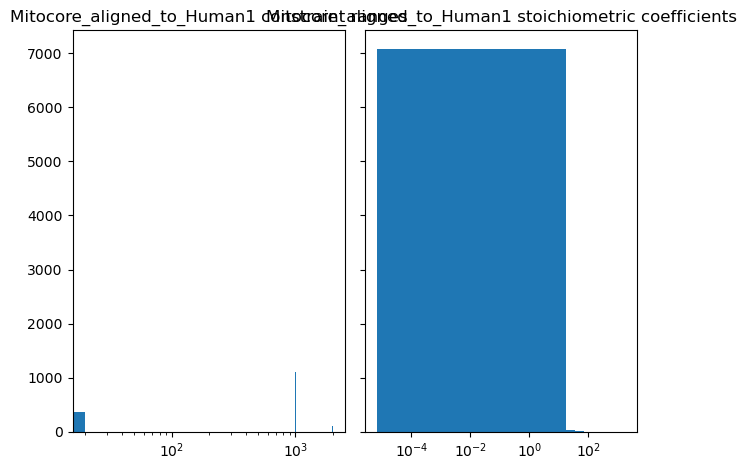

In [8]:
# explore production near optimum: set lower bound of ATP production to mean measured value = 1.707 --> explore ATP production near mean
atp_production_lower_bound = 1.707042254 * 0.95

for model_name, model in models_dict.items():
    with model:
        model.reactions.OF_ATP_MitoCore.lower_bound = atp_production_lower_bound
        
        for reaction in model.reactions:
            if 'ENZYME_' in reaction.id or 'ER_pool_TG_' in reaction.id:
                reaction.upper_bound = reaction.upper_bound * 1000
            else:
                scale_pseudo_metabolite_stoichiometry(reaction, scaling_factor=1/1000)
        
        # sanity check
        print(model.optimize())
        
        get_constraint_distribution(model, model_name)
                
        cobra.io.write_sbml_model(model, f"./../flux_sampling/{model_name}_sampling_model.xml")

In [15]:
def chrr_sampling(model_path, problem_path, threads=16, n_samples = 2_500, seed = 511, n_tuning=5000):
    # import the sbml model and create the polytope from it
    polytope = PolyRoundApi.sbml_to_polytope(model_path)
        
    # check if a sampling problem has ben cached
    if os.path.isfile(problem_path):
        with open(problem_path, "rb") as f:
            problem = pickle.load(f)
        print('loaded problem from cache')
    else:
        # create the sampling problem
        problem = hopsy.Problem(polytope.A, polytope.b) # set the polytype, i.e., the inequality constraints from the constraint based model
        problem = hopsy.add_equality_constraints(problem=problem, A_eq=polytope.S, b_eq=polytope.h) # add the equality constraints from the constraint based model, i.e., the steady state assumption
        # problem = hopsy.add_box_constraints(problem, -1e3, 1e3)

        start = time.perf_counter()
        problem = hopsy.round(problem)
        print(f"Computing rounding transformation for {model_name} took {time.perf_counter()-start} seconds")
        
        with open(problem_path, "wb") as f:
            pickle.dump(problem, f)
        
    # setup markov chains
    chains, rngs = hopsy.setup(problem, seed, n_chains=threads, n_tuning=n_tuning)
    # parameters usually resulted in acceptable results for rhat and effective sample size
    thinning = problem.A.shape[1] * 10 # choose thinning according to number of reacions, as done in the hopsy example with recon3d
    
    # sample!
    start = time.perf_counter()
    accrate, samples = hopsy.sample(chains, rngs, n_samples, thinning=thinning, n_procs=threads, progress_bar=True)
    # accrate is 1 for uniform samples with the default chains given by hopsy.setup()
    print("sampling with internal trafo took", time.perf_counter()-start,"seconds")
    
    # check metrics
    rhat = np.max(hopsy.rhat(samples))
    print("rhat (should be lower 1.01):", rhat)
    ess = np.min(hopsy.ess(samples)) / len(chains)
    print("ess per chain (should be > 400):", ess)
    
        # reshape samples
    flat_samples = samples.reshape(-1, samples.shape[-1])
    results = pandas.DataFrame(flat_samples, columns=polytope.A.columns)
    
    return results

In [16]:
from cobra.sampling import OptGPSampler

def optgp_sampling(model_path, thinning, threads=16, n_samples = 2500, seed = 511):
    model = cobra.io.read_sbml_model(model_path)
    thinning = len(model.reactions)*10 if thinning is None else thinning
    print(thinning)
    optgp = OptGPSampler(model, thinning = thinning, processes=threads, seed=seed)
    results = optgp.sample(n_samples)
    # check validity
    validation = optgp.validate(np.atleast_2d(results))
    
    if len(validation) == 1:
        raise Exception(f'Invalid samples for model {model_name}: {str(validation)}')
    
    # check convergence
    results_numpy = results.to_numpy()
    results_numpy = results_numpy.reshape(threads, int(results_numpy.shape[0]/threads), results_numpy.shape[1])

    rhat = np.max(hopsy.rhat(results_numpy, n_procs=threads))
    print("rhat (should be lower 1.01):", rhat)
    ess = np.min(hopsy.ess(results_numpy, n_procs=threads)) / len(results_numpy)
    print("ess per chain (should be > 400):", ess)
    
    return results


In [ ]:
threads = 16

for model_name, model in models_dict.items():
    
    if not model_name == "Mitocore_aligned_to_Human1":
        continue
    
    print(model_name)
    sampling_problem_path = f"./../flux_sampling/{model_name}_problem.pkl"
    sampling_results_path = f"./../flux_sampling/{model_name}_sampling_results.pkl"
    
    if os.path.isfile(sampling_results_path):
        with open(sampling_results_path, "rb") as f:
            results = pickle.load(f)
        print('loaded samples from cache')
    else:
        # results = chrr_sampling(model_path=f"./../flux_sampling/{model_name}_sampling_model.xml", problem_path=sampling_problem_path, threads=threads, n_samples=2500, seed=511)
        results = optgp_sampling(model_path=f"./../flux_sampling/{model_name}_sampling_model.xml", thinning=None, threads=threads, n_samples=40000, seed=511)
    
        with open(sampling_results_path, "wb") as f:
            pickle.dump(results, f)
    
    ## process sampling results
    
    # get only reactions of interest
    sampling_results = results[sampling_comparison_dict["reaction"]]
    pdhm_results = results["PDHm_GPRSPLIT_1"] if "PDHm_GPRSPLIT_1" in results.columns else results["PDHm"]

    # data formatting for plotting: stack every column and generate a long data frame
    sample_results_with_index = sampling_results.reset_index()
    pdhm_data[model_name] = list(pdhm_results.values)
        
    for reaction in sampling_comparison_dict["reaction"]:
        fluxes = sample_results_with_index.loc[:,["index", reaction]]
        sampling_comparison_dict[model_name].append(fluxes)
    
    # calculate glyco vs OXPHOS ATP production fraction for every sample
    glyco_fractions = []
    oxphos_fractions = []
    
    glyco_absolute = []
    oxphos_absolute = []
    
    # get sampling results for glyco and oxphos reactions
    atp_reaction_names = list(glycolysis_fluxes[model_name].keys()) + list(oxphos_fluxes[model_name].keys())
    
    sample_results_atp = results[atp_reaction_names]
    
    for index, row in sample_results_atp.iterrows():
        glyco_fraction, oxphos_fraction, glyco_net, oxphos_net = get_ATP_production_fraction(row.to_dict(), glycolysis_fluxes[model_name], oxphos_fluxes[model_name], verbose=False)
        glyco_fractions.append(glyco_fraction)
        oxphos_fractions.append(oxphos_fraction)
        glyco_absolute.append(glyco_net)
        oxphos_absolute.append(oxphos_net)
    
    glyco_oxphos_splits_sampling["model"].append(model_name)
    glyco_oxphos_splits_sampling["glycolysis_fraction"].append(glyco_fractions)
    glyco_oxphos_splits_sampling["oxphos_fraction"].append(oxphos_fractions)
    glyco_oxphos_splits_sampling["glycolysis_net_flux"].append(glyco_absolute)
    glyco_oxphos_splits_sampling["oxphos_net_flux"].append(oxphos_absolute)                                                         

Mitocore_aligned_to_Human1
15820


In [ ]:
import matplotlib.cm as cm

cmap = cm.get_cmap("YlGnBu", len(model_paths_dict) + 1)
palette = [cmap(i) for i in range(1, len(model_paths_dict) + 1)]
# palette = mpl.colormaps['Set2'].colors[0:4]

C:\Users\emanuel.lange\AppData\Local\Temp\ipykernel_11540\1354430572.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("YlGnBu", len(model_paths_dict) + 1)


In [ ]:
palette[0] = [color * 0.9 for color in palette[0]]

In [ ]:
def density_plots(model_names, model_to_fluxes_df, measurement, palette):
    
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 6), gridspec_kw={'height_ratios': [3, 1]})
    
    for i, model_name in enumerate(model_names):
        
        mean = model_to_fluxes_df.loc[model_to_fluxes_df['model'] == model_name, 'fluxes'].mean()
        median = model_to_fluxes_df.loc[model_to_fluxes_df['model'] == model_name, 'fluxes'].median()
        
        sns.kdeplot(
            data=model_to_fluxes_df.loc[model_to_fluxes_df['model'] == model_name],
            x='fluxes',
            color=palette[i],
            bw_adjust=.2,
            multiple="stack",
            cut=0,
            alpha=0.8,
            linewidth=3,
            fill=False,
            label=model_name,
            ax=ax1
            )
            # median value
        ax1.axvline(median, color=palette[i], linestyle='--', linewidth=2)
        ax1.text(median, 0.98 - i*0.05, f"{median:.2f}", color='k',
                    ha='left', va='top', transform=ax1.get_xaxis_transform(), bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.05'))
        
    # measured values value
    if measurement is not None:
        ax1.axvline(measurement, color='k', linestyle='--', linewidth=2)
        ax1.text(measurement, 0.98 - (i+1)*0.05, f"{measurement:.2f}", color='k',
                ha='left', va='top', transform=ax1.get_xaxis_transform(), bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.05'))
    
    # ax.set_xlim([1.2, 2])
    ax1.set_xlabel('Flux (mmol/(gdw h))')
    ax1.set_title(reaction)
    ax1.legend()
            
    sns.boxplot(
        data=model_to_fluxes_df,
        x='fluxes',
        y='model',
        hue='model',
        width=.5,
        palette=palette,
        legend=False,
        flierprops={"marker": "."},
        ax=ax2
    )
    ax2.set_yticklabels([])

MitoCore_Original_plt:
median: -0.17861299978255837
Mitocore_Preliminary:
median: -0.11676281397279328
Mitocore_MitoMammal:
median: -0.16818344346288738
Mitocore_aligned_to_Human1:
median: -0.18159681408749104


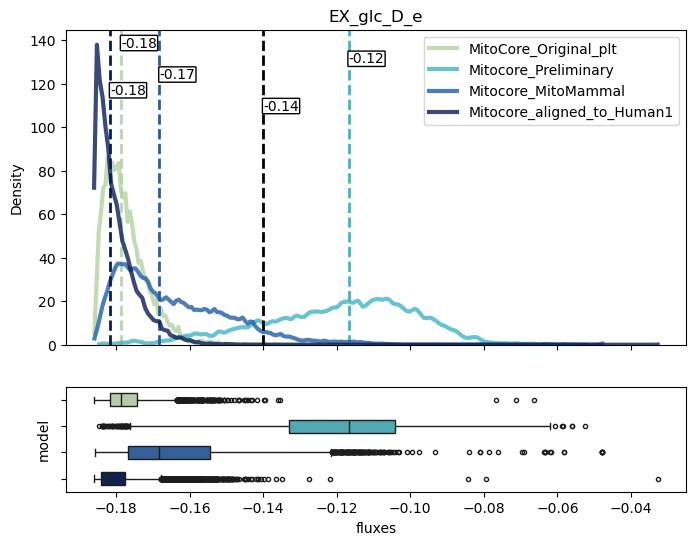

MitoCore_Original_plt:
median: -0.03317101870344039
Mitocore_Preliminary:
median: -0.0021024412145077167
Mitocore_MitoMammal:
median: -0.0024899732226902564
Mitocore_aligned_to_Human1:
median: -0.10726830853275314


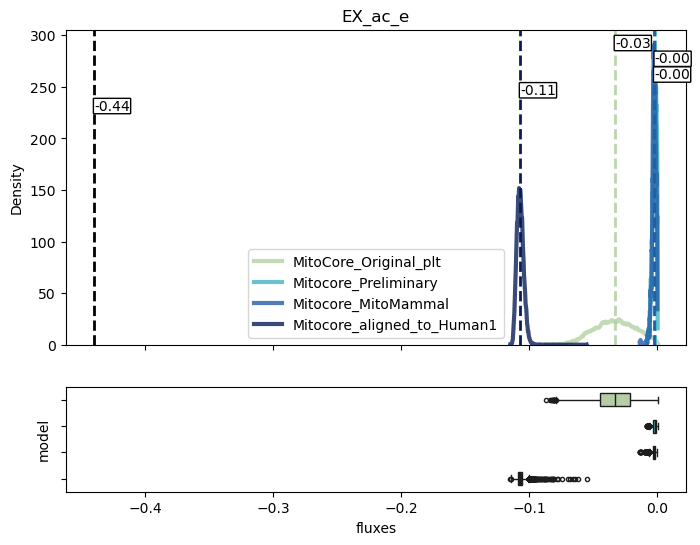

MitoCore_Original_plt:
median: 0.008435178549219782
Mitocore_Preliminary:
median: 0.037983520538603786
Mitocore_MitoMammal:
median: 0.012656547176251328
Mitocore_aligned_to_Human1:
median: 0.32034281621863214


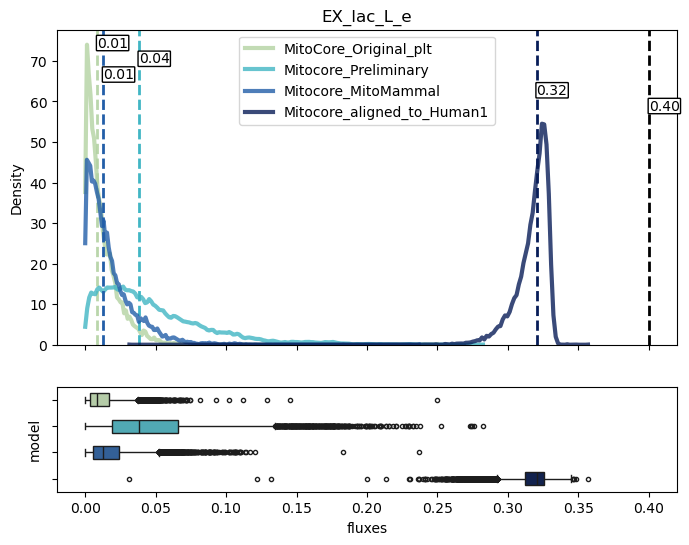

MitoCore_Original_plt:
median: 0.0
Mitocore_Preliminary:
median: 0.0
Mitocore_MitoMammal:
median: 0.0
Mitocore_aligned_to_Human1:
median: 0.0


C:\Users\emanuel.lange\AppData\Local\Temp\ipykernel_11540\4280408991.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\emanuel.lange\AppData\Local\Temp\ipykernel_11540\4280408991.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\emanuel.lange\AppData\Local\Temp\ipykernel_11540\4280408991.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\emanuel.lange\AppData\Local\Temp\ipykernel_11540\4280408991.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\emanuel.lange\AppData\Local\Temp\ipykernel_11540\4280408991.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start

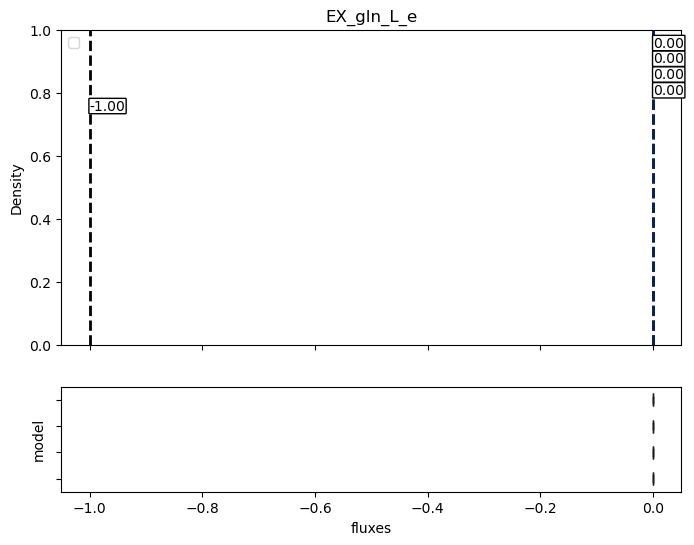

MitoCore_Original_plt:
median: 0.0007346541988817066
Mitocore_Preliminary:
median: 0.0011674763620407474
Mitocore_MitoMammal:
median: 0.001158273285684695
Mitocore_aligned_to_Human1:
median: 0.0005434278495493399


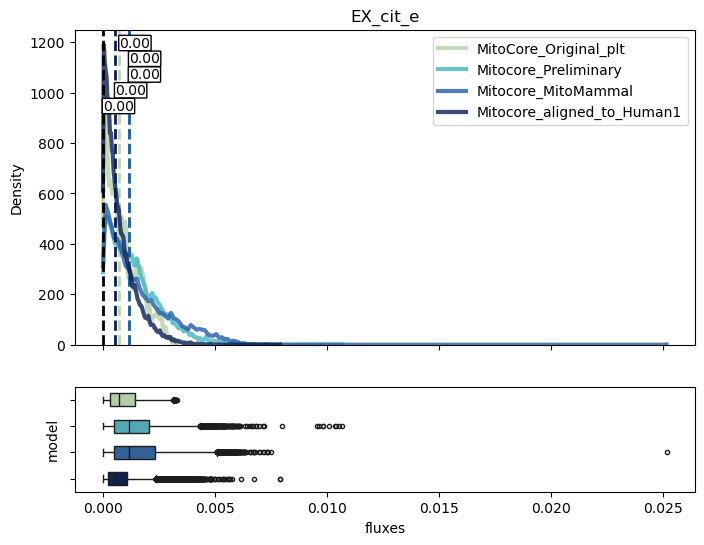

MitoCore_Original_plt:
median: 1.7166498843226505
Mitocore_Preliminary:
median: 1.6412909332911527
Mitocore_MitoMammal:
median: 1.6544698713657024
Mitocore_aligned_to_Human1:
median: 1.631556380745172


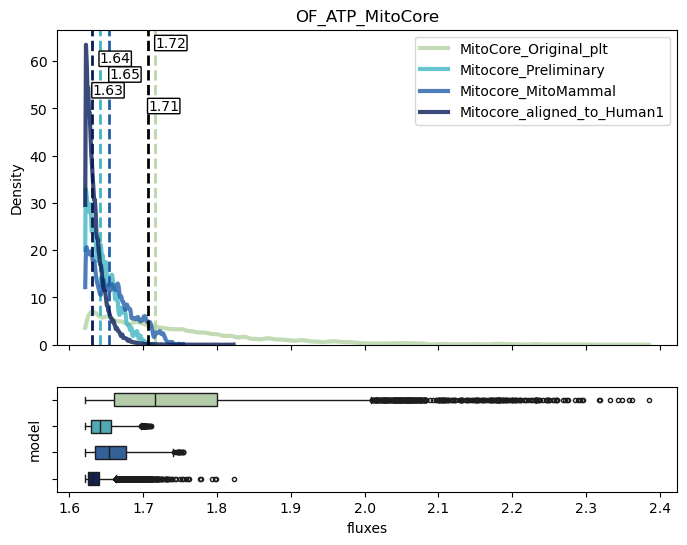

In [ ]:
for reaction_index in range(0, len(sampling_comparison_dict["reaction"])):
    
    reaction = sampling_comparison_dict["reaction"][reaction_index]
    measurement = sampling_comparison_dict["measured_flux"][reaction_index]
        
    plot_data = {"model": [], "fluxes": []}
    
    medians = []
    means = []

    for model_name in model_paths_dict.keys():
        # create a density plot and show the FBA value as vertical line
        data = list(sampling_comparison_dict[model_name][reaction_index][reaction]) # ATP production fluxes

        print(f'{model_name}:')
        print(f'median: {statistics.median(data)}')
        
        medians.append(statistics.median(data))
        means.append(statistics.mean(data))
        
        plot_data["model"] += [model_name] * len(data)
        plot_data["fluxes"] += data

    plot_data_df = pandas.DataFrame(plot_data)

    try:
        density_plots(model_names=list(model_paths_dict.keys()), model_to_fluxes_df=plot_data_df, measurement=measurement, palette=palette)
        
        plt.savefig(f"./../flux_sampling/{reaction}_sampling_comparison.svg", bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f"Could not create plot for reaction {reaction}: {str(e)}")

MitoCore_Original_plt:
median: 0.3266067554791833
Mitocore_Preliminary:
median: 0.19151826257714227
Mitocore_MitoMammal:
median: 0.3240846065216415
Mitocore_aligned_to_Human1:
median: 0.01931074237925803


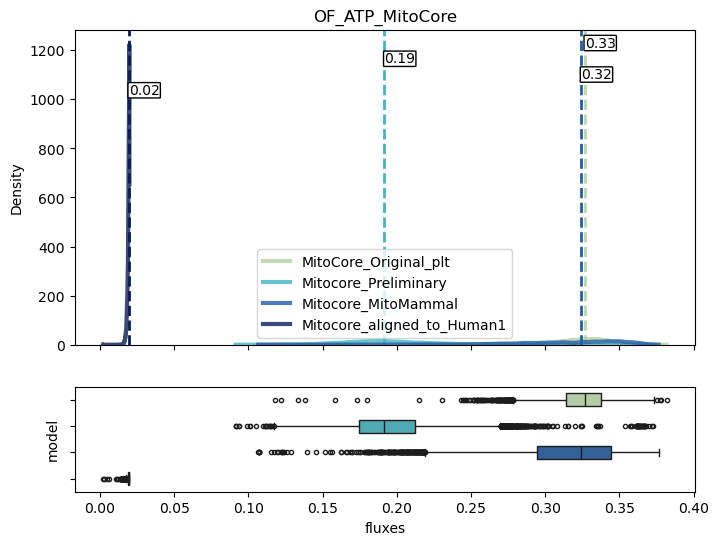

In [ ]:
    
plot_data = {"model": [], "fluxes": []}

for model_name in model_paths_dict.keys():
    # create a density plot and show the FBA value as vertical line
    data = list(pdhm_data[model_name]) # ATP production fluxes

    print(f'{model_name}:')
    print(f'median: {statistics.median(data)}')
    
    plot_data["model"] += [model_name] * len(data)
    plot_data["fluxes"] += data

plot_data_df = pandas.DataFrame(plot_data)

try:
    density_plots(model_names=list(model_paths_dict.keys()), model_to_fluxes_df=plot_data_df, measurement=None, palette=palette)
    
    plt.savefig(f"./../flux_sampling/{reaction}_sampling_comparison.svg", bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"Could not create plot for reaction {reaction}: {str(e)}")

MitoCore_Original_plt:
median: 0.11367223537021309
Mitocore_Preliminary:
median: 0.17059211448293352
Mitocore_MitoMammal:
median: 0.24884067408528282
Mitocore_aligned_to_Human1:
median: 0.23787717287689558


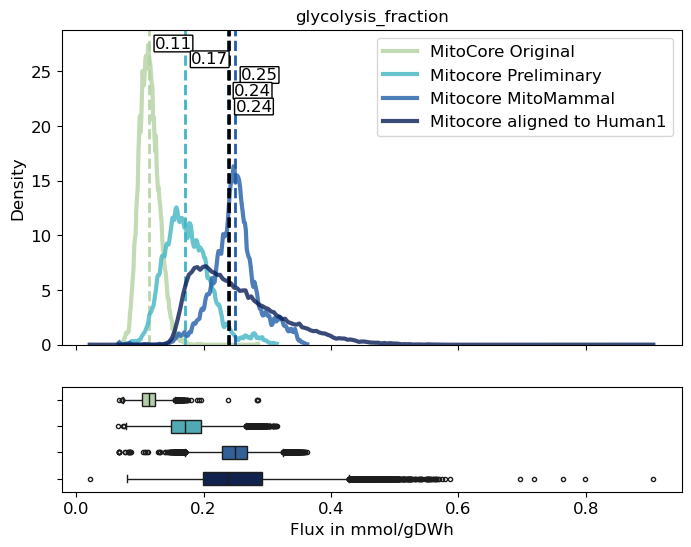

MitoCore_Original_plt:
median: 0.8863277646297869
Mitocore_Preliminary:
median: 0.8294078855170666
Mitocore_MitoMammal:
median: 0.7511593259147172
Mitocore_aligned_to_Human1:
median: 0.7621228271231044


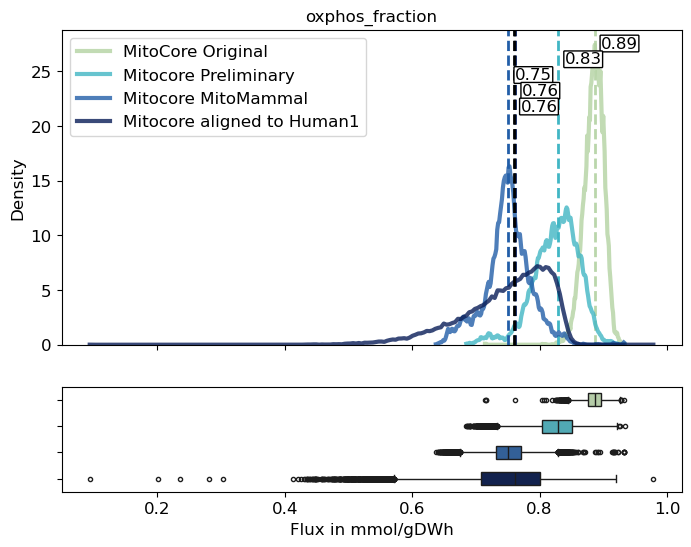

MitoCore_Original_plt:
median: 0.3453076168404979
Mitocore_Preliminary:
median: 0.2747512423420406
Mitocore_MitoMammal:
median: 0.38000595637678913
Mitocore_aligned_to_Human1:
median: 0.558946779748064


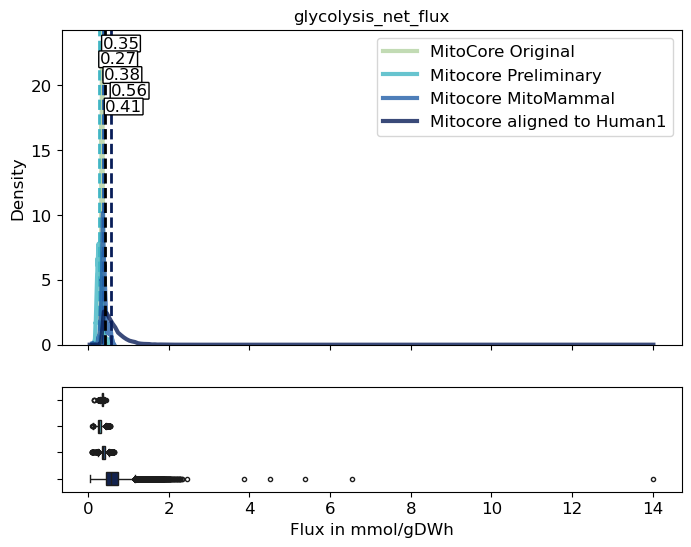

MitoCore_Original_plt:
median: 2.6795062995899976
Mitocore_Preliminary:
median: 1.3410723710909833
Mitocore_MitoMammal:
median: 1.174475776771863
Mitocore_aligned_to_Human1:
median: 1.783462897900585


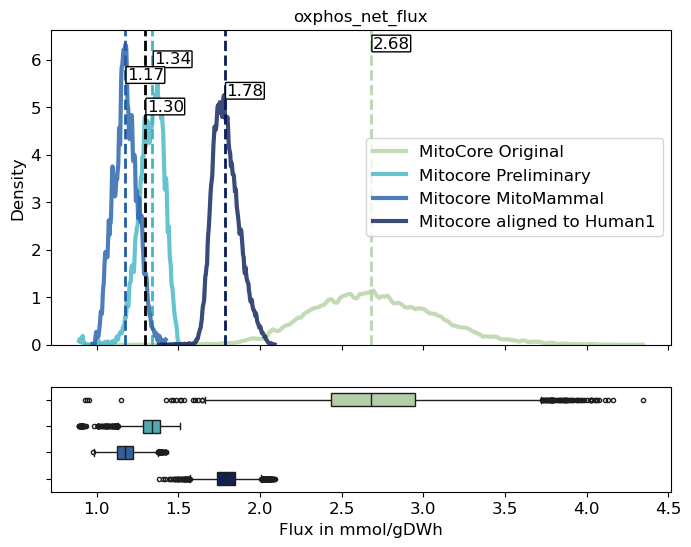

In [ ]:
plots = ["glycolysis_fraction", "oxphos_fraction", "glycolysis_net_flux", "oxphos_net_flux"]
plot_model_names = ['MitoCore Original', 'Mitocore Preliminary', 'Mitocore MitoMammal', 'Mitocore aligned to Human1'] 

for split_index in range(0, len(plots)):
    
    split_name = plots[split_index]
    
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 6), gridspec_kw={'height_ratios': [3, 1]})
    plot_data = {"model": [], "fluxes": []}
    
    medians = []

    for model_index in range(0, len(glyco_oxphos_splits_sampling["model"])):
        # create a density plot and show the FBA value as vertical line
        model = glyco_oxphos_splits_sampling["model"][model_index]
        data = glyco_oxphos_splits_sampling[split_name][model_index]

        print(f'{model}:')
        print(f'median: {statistics.median(data)}')
        
        medians.append(statistics.median(data))
        
        plot_data["model"] += [model] * len(data)
        plot_data["fluxes"] += data

    plot_data_df = pandas.DataFrame(plot_data)
    
    measurement = glyco_oxphos_splits[split_name][0]

    try:
        for i, model_name in enumerate(model_paths_dict.keys()):
            sns.kdeplot(
                data=plot_data_df.loc[plot_data_df['model'] == model_name],
                x='fluxes',
                color=palette[i],
                bw_adjust=.2,
                multiple="stack",
                cut=0,
                alpha=0.8,
                linewidth=3,
                fill=False,
                label=plot_model_names[i],
                ax=ax1,
                )
            ax1.axvline(medians[i], color=palette[i], linestyle='--', linewidth=2) # median value
            ax1.text(medians[i]+0.01, 0.98 - i*0.05, f"{medians[i]:.2f}", color='k', fontsize=12,
                    ha='left', va='top', transform=ax1.get_xaxis_transform(), bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.05'))
        
        # if split_index == 0:
        ax1.axvline(measurement, color='k', linestyle='--', linewidth=2) # measured glycolysis split
        ax1.text(measurement+0.01, 0.98 - (i+1)*0.05, f"{measurement:.2f}", color='k', fontsize=12,
                    ha='left', va='top', transform=ax1.get_xaxis_transform(), bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.05'))
        
        # ax.set_xlim([1.2, 2])
        if split_name == "glycolysis_fraction" or split_name == "oxphos_fraction":
            ax1.set_xlabel('ATP production ratio')
        else:
            ax1.set_xlabel('ATP production (mmol/(gdw h))')
            
        ax1.tick_params(axis='both', which='major', labelsize=12)
        ax1.set_ylabel('Density', fontsize=12)
        ax1.set_title(split_name)
        ax1.set_xlabel('Flux in mmol/gDWh', fontsize=12)
        ax1.legend(fontsize=12)
        
        sns.boxplot(
            data=plot_data_df,
            x='fluxes',
            y='model',
            hue='model',
            width=.5,
            palette=palette,
            legend=False,
            flierprops={"marker": "."},
            ax=ax2
        )
        ax2.set_yticklabels([])
        ax2.set_ylabel('')
        ax2.set_xlabel('Flux in mmol/gDWh', fontsize=12)
        ax2.tick_params(axis='both', which='major', labelsize=12)
        
        plt.savefig(f"./../flux_sampling/{split_name}_sampling_comparison.svg", bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f"Could not create plot for reaction {reaction}: {str(e)}")